In [1]:
# Cell 1 - Load and validate the seven primary RQ2 results
from pathlib import Path

import numpy as np
import pandas as pd


def find_phase1_dir(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "outputs/prediction").is_dir():
            return candidate
        nested = candidate / "phase1"
        if (nested / "outputs/prediction").is_dir():
            return nested
    raise FileNotFoundError("Could not locate the phase1 directory.")


def require(condition: bool, message: str) -> None:
    """Raise a clear integrity error."""
    if not condition:
        raise ValueError(message)


PHASE1_DIR = find_phase1_dir(Path.cwd())
OUTPUT_DIR = PHASE1_DIR / "outputs" / "bh_fdr"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ALPHA = 0.05
EXPECTED_PAIRED_SESSIONS = 20
METRIC_ORDER = (
    "Mean_CC",
    "Mean_NRMSE",
    "DET",
    "Lmean",
    "LAM",
    "TT",
    "LLE",
)
METRIC_METADATA = {
    "Mean_CC": {
        "domain": "Prediction",
        "construct": "Forecastability",
        "expected_sign": -1,
        "direction_label": "lower in Drowsy",
    },
    "Mean_NRMSE": {
        "domain": "Prediction",
        "construct": "Forecastability",
        "expected_sign": 1,
        "direction_label": "higher in Drowsy",
    },
    "DET": {
        "domain": "RQA",
        "construct": "Diagonal recurrence",
        "expected_sign": -1,
        "direction_label": "lower in Drowsy",
    },
    "Lmean": {
        "domain": "RQA",
        "construct": "Diagonal recurrence",
        "expected_sign": -1,
        "direction_label": "lower in Drowsy",
    },
    "LAM": {
        "domain": "RQA",
        "construct": "Laminar recurrence",
        "expected_sign": 1,
        "direction_label": "higher in Drowsy",
    },
    "TT": {
        "domain": "RQA",
        "construct": "Laminar recurrence",
        "expected_sign": 1,
        "direction_label": "higher in Drowsy",
    },
    "LLE": {
        "domain": "Local divergence",
        "construct": "Local trajectory divergence",
        "expected_sign": -1,
        "direction_label": "lower in Drowsy",
    },
}

SOURCE_SPECS = (
    {
        "path": (
            PHASE1_DIR
            / "outputs/prediction/prediction_state_comparison_60s_processed.csv"
        ),
        "metrics": ("Mean_CC", "Mean_NRMSE"),
        "columns": {
            "metric": "Metric",
            "n_sessions": "n_paired",
            "median_awake": "Awake_median",
            "median_drowsy": "Drowsy_median",
            "median_delta": "Median_Delta",
            "ci95_low": "CI_low",
            "ci95_high": "CI_high",
            "p_raw": "raw_p",
            "rank_biserial": "r_rb",
            "n_delta_positive": "n_positive",
            "n_delta_negative": "n_negative",
            "n_delta_zero": "n_zero",
        },
    },
    {
        "path": PHASE1_DIR / "outputs/rqa/rqa_state_comparison_60s_processed.csv",
        "metrics": ("DET", "Lmean", "LAM", "TT"),
        "columns": {
            "metric": "Metric",
            "n_sessions": "n_paired",
            "awake_median": "Awake_median",
            "drowsy_median": "Drowsy_median",
            "median_delta": "Median_Delta",
            "bootstrap_ci_low": "CI_low",
            "bootstrap_ci_high": "CI_high",
            "raw_p_value": "raw_p",
            "rank_biserial_r_rb": "r_rb",
            "n_positive": "n_positive",
            "n_negative": "n_negative",
            "n_zero": "n_zero",
        },
    },
    {
        "path": PHASE1_DIR / "outputs/lle/lle_state_comparison_60s_processed.csv",
        "metrics": ("LLE",),
        "columns": {
            "metric": "Metric",
            "n_sessions": "n_paired",
            "awake_median": "Awake_median",
            "drowsy_median": "Drowsy_median",
            "median_delta": "Median_Delta",
            "bootstrap_ci_low": "CI_low",
            "bootstrap_ci_high": "CI_high",
            "raw_p_value": "raw_p",
            "rank_biserial_r_rb": "r_rb",
            "n_positive": "n_positive",
            "n_negative": "n_negative",
            "n_zero": "n_zero",
        },
    },
)

normalized_sources = []
raw_sources = {}
for source_spec in SOURCE_SPECS:
    source_path = source_spec["path"]
    require(source_path.is_file(), f"Missing source: {source_path}")
    source = pd.read_csv(source_path)
    raw_sources[source_path.name] = source.copy()
    required_columns = set(source_spec["columns"])
    missing_columns = required_columns.difference(source.columns)
    require(
        not missing_columns,
        f"Missing columns in {source_path.name}: {sorted(missing_columns)}",
    )
    adjusted_columns = [
        column
        for column in source.columns
        if column.casefold().startswith(("p_adjusted", "q_"))
    ]
    for column in adjusted_columns:
        require(
            source[column].isna().all(),
            f"Source already contains adjusted values in {column}.",
        )
    selected = source.loc[
        source["metric"].isin(source_spec["metrics"]),
        list(source_spec["columns"]),
    ].rename(columns=source_spec["columns"])
    require(
        set(selected["Metric"]) == set(source_spec["metrics"]),
        f"Primary metric mismatch in {source_path.name}.",
    )
    selected["source_file"] = source_path.name
    normalized_sources.append(selected)

primary_results = pd.concat(normalized_sources, ignore_index=True)
primary_results["metric_order"] = primary_results["Metric"].map(
    dict(zip(METRIC_ORDER, range(len(METRIC_ORDER))))
)
primary_results = (
    primary_results.sort_values("metric_order")
    .drop(columns="metric_order")
    .reset_index(drop=True)
)
require(len(primary_results) == 7, "Expected exactly seven primary tests.")
require(
    tuple(primary_results["Metric"]) == METRIC_ORDER,
    "Primary metric order or membership is incorrect.",
)
require(primary_results["Metric"].is_unique, "Metric names are duplicated.")
require(
    primary_results["n_paired"].eq(EXPECTED_PAIRED_SESSIONS).all(),
    "Every metric must use exactly 20 paired sessions.",
)
require(
    np.isfinite(primary_results["raw_p"]).all()
    and primary_results["raw_p"].between(0.0, 1.0).all(),
    "Raw p-values must be finite and within [0, 1].",
)
require(
    np.isfinite(
        primary_results[
            [
                "Awake_median",
                "Drowsy_median",
                "Median_Delta",
                "CI_low",
                "CI_high",
                "r_rb",
            ]
        ].to_numpy(dtype=float)
    ).all(),
    "Effect estimates must be finite.",
)
require(
    primary_results["CI_low"].le(primary_results["CI_high"]).all(),
    "Every confidence interval must satisfy CI_low <= CI_high.",
)
direction_count_sign = np.sign(
    primary_results["n_positive"] - primary_results["n_negative"]
)
require(
    np.array_equal(
        np.sign(primary_results["Median_Delta"]), direction_count_sign
    ),
    "Median Delta direction disagrees with session direction counts.",
)
require(
    np.array_equal(
        np.sign(primary_results["Median_Delta"]),
        np.sign(primary_results["r_rb"]),
    ),
    "Median Delta direction disagrees with rank-biserial direction.",
)
require(
    primary_results[["n_positive", "n_negative", "n_zero"]]
    .sum(axis=1).eq(EXPECTED_PAIRED_SESSIONS).all(),
    "Session direction counts must sum to 20.",
)

lle_sensitivity_path = (
    PHASE1_DIR / "outputs/lle/lle_qc_sensitivity_60s_processed.csv"
)
lle_sensitivity = pd.read_csv(lle_sensitivity_path)
lle_primary_qc = lle_sensitivity.loc[
    lle_sensitivity["criterion"].astype(str).str.casefold().eq("primary")
]
require(len(lle_primary_qc) == 1, "Expected one primary LLE QC row.")
require(
    np.isclose(
        lle_primary_qc["fit_r2_threshold"].iloc[0], 0.90
    ),
    "LLE primary result must use fit R2 >= 0.90.",
)
lle_source = raw_sources["lle_state_comparison_60s_processed.csv"]
require(
    int(lle_source["n_valid_windows"].iloc[0])
    == int(lle_primary_qc["retained_windows"].iloc[0]),
    "LLE source does not match the primary R2 >= 0.90 analysis.",
)

print(
    primary_results[
        [
            "Metric",
            "n_paired",
            "Median_Delta",
            "CI_low",
            "CI_high",
            "raw_p",
            "r_rb",
            "n_positive",
            "n_negative",
            "n_zero",
        ]
    ].to_string(index=False, float_format=lambda value: f"{value:.5g}")
)
print("\nValidation: PASS | Seven raw primary tests | 20 paired sessions each")


    Metric  n_paired  Median_Delta     CI_low    CI_high      raw_p     r_rb  n_positive  n_negative  n_zero
   Mean_CC        20     -0.033871  -0.059465 -0.0043483   0.021484 -0.58095           5          15       0
Mean_NRMSE        20      0.029424  0.0046511   0.053021  0.0072956  0.66667          15           5       0
       DET        20     -0.018645  -0.036354 -0.0068988   0.021484 -0.58095           5          15       0
     Lmean        20     -0.062991   -0.12473  -0.013938   0.058258 -0.48571           4          16       0
       LAM        20      0.016509 -0.0043612   0.063484    0.14291  0.38095          13           7       0
        TT        20     0.0095155  -0.003444   0.015962    0.20245  0.33333          14           6       0
       LLE        20      -0.03757  -0.053698  -0.022976 0.00070763 -0.80952           4          16       0

Validation: PASS | Seven raw primary tests | 20 paired sessions each


In [2]:
# Cell 2 - Apply Benjamini-Hochberg FDR once across seven tests
def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    """Return monotone Benjamini-Hochberg adjusted p-values."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values, kind="stable")
    ranks = np.arange(1, len(p_values) + 1, dtype=float)
    sorted_adjusted = p_values[order] * len(p_values) / ranks
    sorted_adjusted = np.minimum.accumulate(sorted_adjusted[::-1])[::-1]
    adjusted = np.empty_like(sorted_adjusted)
    adjusted[order] = np.clip(sorted_adjusted, 0.0, 1.0)
    return adjusted


primary_results["q_BH"] = benjamini_hochberg(
    primary_results["raw_p"].to_numpy(dtype=float)
)
primary_results["reject_BH"] = primary_results["q_BH"].lt(ALPHA)
sorted_for_check = primary_results.sort_values("raw_p")
require(
    sorted_for_check["q_BH"].is_monotonic_increasing,
    "BH q-values must be monotone in sorted raw p-values.",
)
print(
    primary_results[["Metric", "raw_p", "q_BH", "reject_BH"]]
    .to_string(index=False, float_format=lambda value: f"{value:.6g}")
)
print("\nBH-FDR applied once across all seven predefined primary tests.")


    Metric       raw_p       q_BH  reject_BH
   Mean_CC   0.0214844  0.0375977       True
Mean_NRMSE  0.00729561  0.0255346       True
       DET   0.0214844  0.0375977       True
     Lmean   0.0582581  0.0815613      False
       LAM    0.142906   0.166724      False
        TT     0.20245    0.20245      False
       LLE 0.000707626 0.00495338       True

BH-FDR applied once across all seven predefined primary tests.


In [3]:
# Cell 3 - Construct the final RQ2 evidence table
evidence_rows = []
for row in primary_results.to_dict(orient="records"):
    metadata = METRIC_METADATA[row["Metric"]]
    expected_count = (
        row["n_negative"]
        if metadata["expected_sign"] < 0
        else row["n_positive"]
    )
    evidence_rows.append(
        {
            "Domain": metadata["domain"],
            "Construct": metadata["construct"],
            "Metric": row["Metric"],
            "n_paired": int(row["n_paired"]),
            "Awake_median": row["Awake_median"],
            "Drowsy_median": row["Drowsy_median"],
            "Median_Delta": row["Median_Delta"],
            "CI_low": row["CI_low"],
            "CI_high": row["CI_high"],
            "raw_p": row["raw_p"],
            "r_rb": row["r_rb"],
            "q_BH": row["q_BH"],
            "BH_supported": bool(row["reject_BH"]),
            "expected_direction": metadata["direction_label"],
            "Direction_count": (
                f"{int(expected_count)}/{int(row['n_paired'])} "
                f"{metadata['direction_label']}"
            ),
            "n_positive": int(row["n_positive"]),
            "n_negative": int(row["n_negative"]),
            "n_zero": int(row["n_zero"]),
        }
    )
final_evidence_table = pd.DataFrame(evidence_rows)
final_table_path = (
    OUTPUT_DIR / "rq2_primary_bh_fdr_60s_processed.csv"
)
final_evidence_table.to_csv(
    final_table_path, index=False, float_format="%.10g"
)

publication_table = final_evidence_table[
    [
        "Domain",
        "Metric",
        "Awake_median",
        "Drowsy_median",
        "Median_Delta",
        "CI_low",
        "CI_high",
        "r_rb",
        "q_BH",
        "Direction_count",
    ]
].copy()
publication_table["95% CI"] = publication_table.apply(
    lambda row: f"[{row['CI_low']:.4f}, {row['CI_high']:.4f}]",
    axis=1,
)
publication_table = publication_table.drop(columns=["CI_low", "CI_high"])
print(
    publication_table.to_string(
        index=False, float_format=lambda value: f"{value:.4f}"
    )
)
print(f"\nSaved: {final_table_path}")


          Domain     Metric  Awake_median  Drowsy_median  Median_Delta    r_rb   q_BH        Direction_count             95% CI
      Prediction    Mean_CC        0.6890         0.6635       -0.0339 -0.5810 0.0376  15/20 lower in Drowsy [-0.0595, -0.0043]
      Prediction Mean_NRMSE        0.6392         0.6657        0.0294  0.6667 0.0255 15/20 higher in Drowsy   [0.0047, 0.0530]
             RQA        DET        0.7126         0.6983       -0.0186 -0.5810 0.0376  15/20 lower in Drowsy [-0.0364, -0.0069]
             RQA      Lmean        4.0132         3.9151       -0.0630 -0.4857 0.0816  16/20 lower in Drowsy [-0.1247, -0.0139]
             RQA        LAM        0.3146         0.3289        0.0165  0.3810 0.1667 13/20 higher in Drowsy  [-0.0044, 0.0635]
             RQA         TT        2.0267         2.0331        0.0095  0.3333 0.2024 14/20 higher in Drowsy  [-0.0034, 0.0160]
Local divergence        LLE        0.8109         0.7947       -0.0376 -0.8095 0.0050  16/20 lower in Dr

In [4]:
# Cell 4 - Classify metric and construct-level evidence
classification_rows = []
for row in final_evidence_table.to_dict(orient="records"):
    expected_sign = METRIC_METADATA[row["Metric"]]["expected_sign"]
    median_coherent = np.sign(row["Median_Delta"]) == expected_sign
    effect_coherent = np.sign(row["r_rb"]) == expected_sign
    session_coherent = (
        row["n_negative"] > row["n_positive"]
        if expected_sign < 0
        else row["n_positive"] > row["n_negative"]
    )
    ci_compatible = (
        row["CI_low"] < 0.0
        if expected_sign < 0
        else row["CI_high"] > 0.0
    )
    direction_coherent = all(
        (median_coherent, effect_coherent, session_coherent, ci_compatible)
    )
    if row["BH_supported"] and direction_coherent:
        evidence_class = "Strong multiplicity-controlled support"
    elif not row["BH_supported"] and direction_coherent:
        evidence_class = "Directionally consistent but not BH-supported"
    else:
        evidence_class = "Direction not coherent; review required"
    classification_rows.append(
        {
            "Metric": row["Metric"],
            "direction_coherent": direction_coherent,
            "CI_excludes_zero": (
                row["CI_low"] > 0.0 or row["CI_high"] < 0.0
            ),
            "Evidence_class": evidence_class,
        }
    )
classification = pd.DataFrame(classification_rows)
final_evidence_table = final_evidence_table.merge(
    classification, on="Metric", how="left", validate="one_to_one"
)
final_evidence_table.to_csv(
    final_table_path, index=False, float_format="%.10g"
)
print(
    final_evidence_table[
        ["Construct", "Metric", "q_BH", "Evidence_class"]
    ].to_string(index=False, float_format=lambda value: f"{value:.4f}")
)

print("\nConstruct-level evidence:")
for construct in final_evidence_table["Construct"].drop_duplicates():
    construct_rows = final_evidence_table.loc[
        final_evidence_table["Construct"].eq(construct)
    ]
    supported = construct_rows.loc[
        construct_rows["BH_supported"], "Metric"
    ].tolist()
    directional = construct_rows.loc[
        ~construct_rows["BH_supported"]
        & construct_rows["direction_coherent"],
        "Metric",
    ].tolist()
    supported_text = ", ".join(supported) if supported else "none"
    directional_text = ", ".join(directional) if directional else "none"
    print(
        f"- {construct}: BH-supported={supported_text}; "
        f"directional-only={directional_text}"
    )


                  Construct     Metric   q_BH                                Evidence_class
            Forecastability    Mean_CC 0.0376        Strong multiplicity-controlled support
            Forecastability Mean_NRMSE 0.0255        Strong multiplicity-controlled support
        Diagonal recurrence        DET 0.0376        Strong multiplicity-controlled support
        Diagonal recurrence      Lmean 0.0816 Directionally consistent but not BH-supported
         Laminar recurrence        LAM 0.1667 Directionally consistent but not BH-supported
         Laminar recurrence         TT 0.2024 Directionally consistent but not BH-supported
Local trajectory divergence        LLE 0.0050        Strong multiplicity-controlled support

Construct-level evidence:
- Forecastability: BH-supported=Mean_CC, Mean_NRMSE; directional-only=none
- Diagonal recurrence: BH-supported=DET; directional-only=Lmean
- Laminar recurrence: BH-supported=none; directional-only=LAM, TT
- Local trajectory divergence: B

In [5]:
# Cell 5 - Generate the manuscript-ready RQ2 conclusion
from IPython.display import Markdown, display


def format_finding(row: pd.Series) -> str:
    """Format one manuscript evidence bullet."""
    return (
        f"- **{row['Metric']}**: median Delta={row['Median_Delta']:.4f}, "
        f"95% CI [{row['CI_low']:.4f}, {row['CI_high']:.4f}], "
        f"r_rb={row['r_rb']:.3f}, q_BH={row['q_BH']:.4f}; "
        f"{row['Direction_count']}."
    )


supported_rows = final_evidence_table.loc[
    final_evidence_table["BH_supported"]
]
directional_rows = final_evidence_table.loc[
    ~final_evidence_table["BH_supported"]
    & final_evidence_table["direction_coherent"]
]
supported_text = "\n".join(
    format_finding(row) for _, row in supported_rows.iterrows()
) or "- None."
directional_text = "\n".join(
    format_finding(row) for _, row in directional_rows.iterrows()
) or "- None."

supported_metrics = set(supported_rows["Metric"])
integrated_points = []
if {"Mean_CC", "Mean_NRMSE"}.issubset(supported_metrics):
    integrated_points.append(
        "Drowsiness showed lower forecastability, with lower Mean_CC and "
        "higher Mean_NRMSE."
    )
elif "Mean_CC" in supported_metrics:
    integrated_points.append("Drowsiness showed lower Mean_CC.")
elif "Mean_NRMSE" in supported_metrics:
    integrated_points.append("Drowsiness showed higher Mean_NRMSE.")
if "DET" in supported_metrics:
    integrated_points.append(
        "Lower DET supported reduced diagonal recurrence organization."
    )
if "Lmean" in supported_metrics:
    integrated_points.append(
        "Lower Lmean supported reduced diagonal recurrence persistence."
    )
if {"LAM", "TT"}.intersection(supported_metrics):
    laminar_metrics = ", ".join(
        metric for metric in ("LAM", "TT") if metric in supported_metrics
    )
    integrated_points.append(
        f"{laminar_metrics} provided multiplicity-controlled evidence for "
        "altered laminar recurrence."
    )
if "LLE" in supported_metrics:
    integrated_points.append(
        "Lower LLE supported reduced local trajectory divergence."
    )
integrated_text = " ".join(integrated_points) or (
    "No metric met the multiplicity-controlled support criterion."
)

manuscript_markdown = f"""### RQ2 — Multiplicity-controlled Awake–Drowsy state effects

Seven predefined primary metrics were evaluated across 20 paired sessions
using 60-s Processed PPG:

- Prediction: Mean_CC, Mean_NRMSE
- RQA: DET, Lmean, LAM, TT
- Local divergence: LLE

Raw paired Wilcoxon p-values were jointly corrected using the
Benjamini–Hochberg false discovery rate procedure across the seven tests.

#### BH-FDR supported findings

{supported_text}

#### Directionally consistent but weaker findings

{directional_text}

#### Integrated interpretation

{integrated_text}

All effect magnitudes are median paired Delta = Drowsy - Awake, with
bootstrap 95% confidence intervals, matched-pairs rank-biserial effect
sizes, and session-level direction counts. BH-FDR controls multiplicity
and does not replace effect-size or uncertainty reporting.
"""
conclusion_path = OUTPUT_DIR / "rq2_primary_bh_fdr_conclusion.md"
conclusion_path.write_text(manuscript_markdown, encoding="utf-8")
display(Markdown(manuscript_markdown))
print(f"Saved: {conclusion_path}")


### RQ2 — Multiplicity-controlled Awake–Drowsy state effects

Seven predefined primary metrics were evaluated across 20 paired sessions
using 60-s Processed PPG:

- Prediction: Mean_CC, Mean_NRMSE
- RQA: DET, Lmean, LAM, TT
- Local divergence: LLE

Raw paired Wilcoxon p-values were jointly corrected using the
Benjamini–Hochberg false discovery rate procedure across the seven tests.

#### BH-FDR supported findings

- **Mean_CC**: median Delta=-0.0339, 95% CI [-0.0595, -0.0043], r_rb=-0.581, q_BH=0.0376; 15/20 lower in Drowsy.
- **Mean_NRMSE**: median Delta=0.0294, 95% CI [0.0047, 0.0530], r_rb=0.667, q_BH=0.0255; 15/20 higher in Drowsy.
- **DET**: median Delta=-0.0186, 95% CI [-0.0364, -0.0069], r_rb=-0.581, q_BH=0.0376; 15/20 lower in Drowsy.
- **LLE**: median Delta=-0.0376, 95% CI [-0.0537, -0.0230], r_rb=-0.810, q_BH=0.0050; 16/20 lower in Drowsy.

#### Directionally consistent but weaker findings

- **Lmean**: median Delta=-0.0630, 95% CI [-0.1247, -0.0139], r_rb=-0.486, q_BH=0.0816; 16/20 lower in Drowsy.
- **LAM**: median Delta=0.0165, 95% CI [-0.0044, 0.0635], r_rb=0.381, q_BH=0.1667; 13/20 higher in Drowsy.
- **TT**: median Delta=0.0095, 95% CI [-0.0034, 0.0160], r_rb=0.333, q_BH=0.2024; 14/20 higher in Drowsy.

#### Integrated interpretation

Drowsiness showed lower forecastability, with lower Mean_CC and higher Mean_NRMSE. Lower DET supported reduced diagonal recurrence organization. Lower LLE supported reduced local trajectory divergence.

All effect magnitudes are median paired Delta = Drowsy - Awake, with
bootstrap 95% confidence intervals, matched-pairs rank-biserial effect
sizes, and session-level direction counts. BH-FDR controls multiplicity
and does not replace effect-size or uncertainty reporting.


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/bh_fdr/rq2_primary_bh_fdr_conclusion.md


In [6]:
# Cell 6 - Diagnose reverse-direction sessions for every metric
PAIRED_VALUE_SPECS = {
    "Mean_CC": {
        "path": (
            PHASE1_DIR
            / "outputs/prediction/"
            "prediction_state_paired_values_60s_processed.csv"
        ),
        "awake": "mean_cc_awake",
        "drowsy": "mean_cc_drowsy",
        "delta": "delta_mean_cc",
    },
    "Mean_NRMSE": {
        "path": (
            PHASE1_DIR
            / "outputs/prediction/"
            "prediction_state_paired_values_60s_processed.csv"
        ),
        "awake": "mean_nrmse_awake",
        "drowsy": "mean_nrmse_drowsy",
        "delta": "delta_mean_nrmse",
    },
    "DET": {
        "path": (
            PHASE1_DIR
            / "outputs/rqa/rqa_state_paired_values_60s_processed.csv"
        ),
        "awake": "DET_awake",
        "drowsy": "DET_drowsy",
        "delta": "DET_delta",
    },
    "Lmean": {
        "path": (
            PHASE1_DIR
            / "outputs/rqa/rqa_state_paired_values_60s_processed.csv"
        ),
        "awake": "Lmean_awake",
        "drowsy": "Lmean_drowsy",
        "delta": "Lmean_delta",
    },
    "LAM": {
        "path": (
            PHASE1_DIR
            / "outputs/rqa/rqa_state_paired_values_60s_processed.csv"
        ),
        "awake": "LAM_awake",
        "drowsy": "LAM_drowsy",
        "delta": "LAM_delta",
    },
    "TT": {
        "path": (
            PHASE1_DIR
            / "outputs/rqa/rqa_state_paired_values_60s_processed.csv"
        ),
        "awake": "TT_awake",
        "drowsy": "TT_drowsy",
        "delta": "TT_delta",
    },
    "LLE": {
        "path": (
            PHASE1_DIR
            / "outputs/lle/lle_session_paired_deltas_60s_processed.csv"
        ),
        "awake": "lle_awake",
        "drowsy": "lle_drowsy",
        "delta": "delta_lle_drowsy_minus_awake",
    },
}

paired_cache = {}
reverse_rows = []
reverse_counts = []
for metric in METRIC_ORDER:
    spec = PAIRED_VALUE_SPECS[metric]
    source_path = spec["path"]
    if source_path not in paired_cache:
        paired_cache[source_path] = pd.read_csv(source_path)
    paired = paired_cache[source_path]
    required_columns = {
        "session",
        spec["awake"],
        spec["drowsy"],
        spec["delta"],
    }
    require(
        required_columns.issubset(paired.columns),
        f"Missing paired columns for {metric}.",
    )
    require(
        len(paired) == EXPECTED_PAIRED_SESSIONS
        and paired["session"].is_unique,
        f"{metric} must contain 20 unique paired sessions.",
    )
    session_ids = pd.to_numeric(
        paired["session"].astype(str).str.extract(r"(\d+)$", expand=False),
        errors="coerce",
    )
    require(session_ids.notna().all(), f"Could not parse sessions for {metric}.")
    awake = paired[spec["awake"]].to_numpy(dtype=float)
    drowsy = paired[spec["drowsy"]].to_numpy(dtype=float)
    recorded_delta = paired[spec["delta"]].to_numpy(dtype=float)
    calculated_delta = drowsy - awake
    require(
        np.allclose(recorded_delta, calculated_delta, rtol=1e-7, atol=2e-8),
        f"Recorded paired Delta is inconsistent for {metric}.",
    )
    calculated_delta[
        np.isclose(calculated_delta, 0.0, rtol=1e-9, atol=1e-12)
    ] = 0.0
    expected_sign = METRIC_METADATA[metric]["expected_sign"]
    reverse_mask = calculated_delta * expected_sign < 0.0
    reverse_counts.append(
        {
            "Metric": metric,
            "expected_direction": METRIC_METADATA[metric]["direction_label"],
            "n_reverse": int(reverse_mask.sum()),
            "n_paired": len(paired),
        }
    )
    for index in np.flatnonzero(reverse_mask):
        reverse_rows.append(
            {
                "Domain": METRIC_METADATA[metric]["domain"],
                "Metric": metric,
                "Session": f"session_{int(session_ids.iloc[index]):02d}",
                "Awake_value": awake[index],
                "Drowsy_value": drowsy[index],
                "Delta_Drowsy_minus_Awake": calculated_delta[index],
                "expected_direction": (
                    METRIC_METADATA[metric]["direction_label"]
                ),
                "observed_direction": (
                    "higher in Drowsy"
                    if calculated_delta[index] > 0.0
                    else "lower in Drowsy"
                ),
            }
        )

reverse_session_diagnostic = pd.DataFrame(reverse_rows)
reverse_count_summary = pd.DataFrame(reverse_counts)
diagnostic_path = (
    OUTPUT_DIR / "rq2_reverse_direction_sessions_60s_processed.csv"
)
reverse_session_diagnostic.to_csv(
    diagnostic_path, index=False, float_format="%.10g"
)
print("Reverse-direction counts:")
print(reverse_count_summary.to_string(index=False))
print("\nAll reverse-direction sessions:")
print(
    reverse_session_diagnostic.to_string(
        index=False, float_format=lambda value: f"{value:.5f}"
    )
)
print(f"\nSaved: {diagnostic_path}")


Reverse-direction counts:
    Metric expected_direction  n_reverse  n_paired
   Mean_CC    lower in Drowsy          5        20
Mean_NRMSE   higher in Drowsy          5        20
       DET    lower in Drowsy          5        20
     Lmean    lower in Drowsy          4        20
       LAM   higher in Drowsy          7        20
        TT   higher in Drowsy          6        20
       LLE    lower in Drowsy          4        20

All reverse-direction sessions:
          Domain     Metric    Session  Awake_value  Drowsy_value  Delta_Drowsy_minus_Awake expected_direction observed_direction
      Prediction    Mean_CC session_01      0.71626       0.73718                   0.02092    lower in Drowsy   higher in Drowsy
      Prediction    Mean_CC session_04      0.62488       0.66171                   0.03683    lower in Drowsy   higher in Drowsy
      Prediction    Mean_CC session_09      0.67371       0.68369                   0.00998    lower in Drowsy   higher in Drowsy
      Predict

In [7]:
# Cell 7 - Build the complete session-metric direction matrix
direction_rows = []
for metric in METRIC_ORDER:
    spec = PAIRED_VALUE_SPECS[metric]
    paired = paired_cache[spec["path"]]
    session_ids = pd.to_numeric(
        paired["session"].astype(str).str.extract(r"(\d+)$", expand=False),
        errors="coerce",
    )
    awake = paired[spec["awake"]].to_numpy(dtype=float)
    drowsy = paired[spec["drowsy"]].to_numpy(dtype=float)
    differences = drowsy - awake
    zero_mask = np.isclose(differences, 0.0, rtol=1e-9, atol=1e-12)
    expected_sign = METRIC_METADATA[metric]["expected_sign"]
    classifications = np.where(
        zero_mask,
        "Zero",
        np.where(differences * expected_sign > 0.0, "Expected", "Reverse"),
    )
    for session_id, difference, classification in zip(
        session_ids, differences, classifications
    ):
        direction_rows.append(
            {
                "Session": f"session_{int(session_id):02d}",
                "Metric": metric,
                "Delta": difference,
                "Direction_class": classification,
            }
        )

session_metric_directions = pd.DataFrame(direction_rows)
require(
    len(session_metric_directions)
    == EXPECTED_PAIRED_SESSIONS * len(METRIC_ORDER),
    "Direction diagnostic must contain 20 x 7 rows.",
)
require(
    not session_metric_directions.duplicated(["Session", "Metric"]).any(),
    "Session-metric direction keys must be unique.",
)
direction_matrix = session_metric_directions.pivot(
    index="Session", columns="Metric", values="Direction_class"
).reindex(columns=METRIC_ORDER)
reverse_rank = (
    direction_matrix.eq("Reverse").sum(axis=1)
    .rename("n_reverse_of_7").reset_index()
)
reverse_rank["session_number"] = pd.to_numeric(
    reverse_rank["Session"].str.extract(r"(\d+)$", expand=False)
)
reverse_rank = (
    reverse_rank.sort_values(
        ["n_reverse_of_7", "session_number"],
        ascending=[False, True],
    )
    .drop(columns="session_number")
    .reset_index(drop=True)
)
reverse_rank.insert(0, "rank", np.arange(1, len(reverse_rank) + 1))

print("Session x metric direction matrix:")
display(direction_matrix)
print("Reverse-count ranking:")
display(reverse_rank)


Session x metric direction matrix:


Metric,Mean_CC,Mean_NRMSE,DET,Lmean,LAM,TT,LLE
Session,,,,,,,
session_01,Reverse,Reverse,Reverse,Reverse,Expected,Reverse,Expected
session_04,Reverse,Reverse,Reverse,Expected,Reverse,Reverse,Expected
session_05,Expected,Expected,Expected,Expected,Expected,Expected,Expected
session_06,Expected,Expected,Expected,Expected,Expected,Expected,Expected
session_07,Expected,Expected,Expected,Expected,Expected,Expected,Expected
session_08,Expected,Expected,Expected,Expected,Expected,Expected,Expected
session_09,Reverse,Expected,Reverse,Reverse,Reverse,Reverse,Reverse
session_10,Expected,Expected,Expected,Expected,Expected,Expected,Expected
session_11,Expected,Expected,Expected,Expected,Reverse,Expected,Expected


Reverse-count ranking:


,rank,Session,n_reverse_of_7
0,1,session_09,6
1,2,session_13,6
2,3,session_01,5
3,4,session_04,5
4,5,session_17,4
5,6,session_12,3
6,7,session_23,2
7,8,session_11,1
8,9,session_15,1
9,10,session_18,1


In [8]:
# Cell 8 - Quantify cross-metric reverse overlap
reverse_binary = direction_matrix.eq("Reverse").astype(int)
reverse_overlap = reverse_binary.T.dot(reverse_binary).reindex(
    index=METRIC_ORDER, columns=METRIC_ORDER
)
require(
    np.array_equal(
        np.diag(reverse_overlap),
        reverse_binary.sum(axis=0).reindex(METRIC_ORDER).to_numpy(),
    ),
    "Overlap diagonal must equal each metric's reverse count.",
)
print(
    "Cross-metric reverse overlap counts "
    "(diagonal = reverse count per metric):"
)
display(reverse_overlap)
print("Sessions with at least four reverse metrics:")
display(reverse_rank.loc[reverse_rank["n_reverse_of_7"].ge(4)])


Cross-metric reverse overlap counts (diagonal = reverse count per metric):


Metric,Mean_CC,Mean_NRMSE,DET,Lmean,LAM,TT,LLE
Metric,,,,,,,
Mean_CC,5,4,4,2,4,5,2
Mean_NRMSE,4,5,3,1,3,4,1
DET,4,3,5,3,3,4,3
Lmean,2,1,3,4,1,2,2
LAM,4,3,3,1,7,5,2
TT,5,4,4,2,5,6,2
LLE,2,1,3,2,2,2,4


Sessions with at least four reverse metrics:


,rank,Session,n_reverse_of_7
0,1,session_09,6
1,2,session_13,6
2,3,session_01,5
3,4,session_04,5
4,5,session_17,4


In [9]:
# Cell 9 - Compare available QC by reverse-session group
HIGH_REVERSE_MIN_METRICS = 4


def normalize_session_labels(series: pd.Series) -> pd.Series:
    """Return consistent zero-padded session labels."""
    session_ids = pd.to_numeric(
        series.astype(str).str.extract(r"(\d+)$", expand=False),
        errors="coerce",
    )
    require(session_ids.notna().all(), "Session labels could not be parsed.")
    return session_ids.astype(int).map(lambda value: f"session_{value:02d}")


rqa_qc_path = (
    PHASE1_DIR / "outputs/rqa/rqa_session_state_60s_processed.csv"
)
lle_qc_path = (
    PHASE1_DIR
    / "outputs/lle/lle_session_state_summary_60s_processed.csv"
)
rqa_session_qc = pd.read_csv(rqa_qc_path)
lle_session_qc = pd.read_csv(lle_qc_path)
rqa_session_qc["Session"] = normalize_session_labels(
    rqa_session_qc["session"]
)
lle_session_qc["Session"] = normalize_session_labels(
    lle_session_qc["session"]
)
qc_by_session = rqa_session_qc[
    ["Session", "n_windows_awake", "n_windows_drowsy"]
].merge(
    lle_session_qc[
        [
            "Session",
            "n_valid_windows_awake",
            "n_valid_windows_drowsy",
            "median_fit_r2_awake",
            "median_fit_r2_drowsy",
        ]
    ],
    on="Session",
    how="inner",
    validate="one_to_one",
)
qc_by_session = qc_by_session.merge(
    reverse_rank[["Session", "n_reverse_of_7"]],
    on="Session",
    how="inner",
    validate="one_to_one",
)
require(
    len(qc_by_session) == EXPECTED_PAIRED_SESSIONS,
    "QC comparison must retain all 20 sessions.",
)
qc_by_session["n_windows_total"] = (
    qc_by_session["n_windows_awake"]
    + qc_by_session["n_windows_drowsy"]
)
qc_by_session["n_lle_valid_total"] = (
    qc_by_session["n_valid_windows_awake"]
    + qc_by_session["n_valid_windows_drowsy"]
)
qc_by_session["n_lle_excluded"] = (
    qc_by_session["n_windows_total"]
    - qc_by_session["n_lle_valid_total"]
)
require(
    qc_by_session["n_lle_excluded"].ge(0).all(),
    "LLE valid-window count exceeds the shared window denominator.",
)
qc_by_session["lle_exclusion_rate"] = (
    qc_by_session["n_lle_excluded"]
    / qc_by_session["n_windows_total"]
)
qc_by_session["reverse_group"] = np.where(
    qc_by_session["n_reverse_of_7"].ge(HIGH_REVERSE_MIN_METRICS),
    "High reverse (>=4/7)",
    "Remaining (<4/7)",
)

QC_MEASURES = (
    "n_windows_total",
    "n_windows_awake",
    "n_windows_drowsy",
    "n_lle_valid_total",
    "n_valid_windows_awake",
    "n_valid_windows_drowsy",
    "n_lle_excluded",
    "lle_exclusion_rate",
    "median_fit_r2_awake",
    "median_fit_r2_drowsy",
)
qc_comparison_rows = []
for group_name, group in qc_by_session.groupby("reverse_group", sort=False):
    for measure in QC_MEASURES:
        values = group[measure].to_numpy(dtype=float)
        q1, median, q3 = np.percentile(values, [25, 50, 75])
        qc_comparison_rows.append(
            {
                "group": group_name,
                "n_sessions": len(group),
                "measure": measure,
                "median": median,
                "q1": q1,
                "q3": q3,
                "minimum": np.min(values),
                "maximum": np.max(values),
            }
        )
qc_group_comparison = pd.DataFrame(qc_comparison_rows)
print("Available session-level QC by reverse group:")
display(qc_group_comparison.round(4))
print(
    "LLE exclusion rate uses the shared RQA 60-s window count as its "
    "denominator. Prediction window failures, session-level LLE pair "
    "support, sampling rate, and recording QC are unavailable in the "
    "specified final output tables; no values were inferred for them."
)
print("This QC comparison is descriptive; no hypothesis test was run.")


Available session-level QC by reverse group:


,group,n_sessions,measure,median,q1,q3,minimum,maximum
0,High reverse (>=4/7),5,n_windows_total,46.0000,42.0000,48.0000,31.0000,65.0000
1,High reverse (>=4/7),5,n_windows_awake,28.0000,25.0000,29.0000,24.0000,47.0000
2,High reverse (>=4/7),5,n_windows_drowsy,17.0000,14.0000,18.0000,7.0000,23.0000
3,High reverse (>=4/7),5,n_lle_valid_total,46.0000,42.0000,48.0000,31.0000,57.0000
4,High reverse (>=4/7),5,n_valid_windows_awake,28.0000,25.0000,29.0000,24.0000,40.0000
5,High reverse (>=4/7),5,n_valid_windows_drowsy,17.0000,14.0000,17.0000,7.0000,23.0000
6,High reverse (>=4/7),5,n_lle_excluded,0.0000,0.0000,0.0000,0.0000,8.0000
7,High reverse (>=4/7),5,lle_exclusion_rate,0.0000,0.0000,0.0000,0.0000,0.1231
8,High reverse (>=4/7),5,median_fit_r2_awake,0.9784,0.9765,0.9814,0.9619,0.9894
9,High reverse (>=4/7),5,median_fit_r2_drowsy,0.9778,0.9718,0.9866,0.9711,0.9892


LLE exclusion rate uses the shared RQA 60-s window count as its denominator. Prediction window failures, session-level LLE pair support, sampling rate, and recording QC are unavailable in the specified final output tables; no values were inferred for them.
This QC comparison is descriptive; no hypothesis test was run.


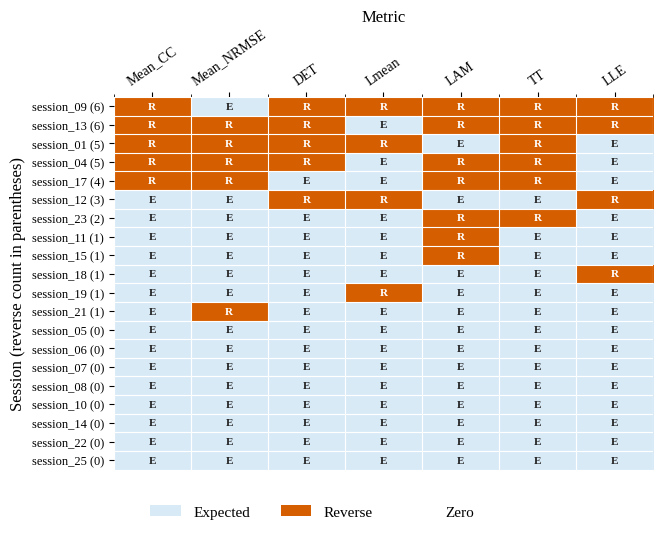

Rows are ranked by reverse count; values and figure are inline only. Font used: Liberation Serif.


In [10]:
# Cell 10 - Display the session-metric direction heatmap inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

required_font = "Times New Roman"
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
active_font = required_font if required_font in available_fonts else "Liberation Serif"
mpl.rcParams.update(
    {
        "font.family": active_font,
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 9,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

ranked_sessions = reverse_rank["Session"].tolist()
ranked_matrix = direction_matrix.reindex(ranked_sessions)
class_codes = {"Expected": 0, "Reverse": 1, "Zero": 2}
annotation_codes = {"Expected": "E", "Reverse": "R", "Zero": "0"}
heatmap_values = ranked_matrix.replace(class_codes).to_numpy(dtype=float)
direction_cmap = ListedColormap(["#D9EAF7", "#D55E00", "#FFFFFF"])
direction_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], direction_cmap.N)

fig, ax = plt.subplots(figsize=(7.10, 5.25))
ax.imshow(
    heatmap_values,
    cmap=direction_cmap,
    norm=direction_norm,
    aspect="auto",
    interpolation="nearest",
)
for row_index, session in enumerate(ranked_matrix.index):
    for column_index, metric in enumerate(ranked_matrix.columns):
        direction_class = ranked_matrix.loc[session, metric]
        text_color = "white" if direction_class == "Reverse" else "#222222"
        ax.text(
            column_index,
            row_index,
            annotation_codes[direction_class],
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
            fontweight="bold",
        )

reverse_count_map = reverse_rank.set_index("Session")["n_reverse_of_7"]
row_labels = [
    f"{session} ({int(reverse_count_map.loc[session])})"
    for session in ranked_matrix.index
]
ax.set_xticks(np.arange(len(METRIC_ORDER)), METRIC_ORDER)
ax.set_yticks(np.arange(len(ranked_matrix)), row_labels)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_xlabel("Metric")
ax.set_ylabel("Session (reverse count in parentheses)")
ax.set_xticks(np.arange(-0.5, len(METRIC_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ranked_matrix), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="x", rotation=35)
ax.spines[:].set_visible(False)

legend_handles = [
    Patch(facecolor=direction_cmap(class_codes[label]), label=label)
    for label in ("Expected", "Reverse", "Zero")
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    frameon=False,
    ncol=3,
)
fig.subplots_adjust(left=0.22, right=0.98, bottom=0.13, top=0.84)
plt.show()
print(
    "Rows are ranked by reverse count; values and figure are inline only. "
    f"Font used: {active_font}."
)


In [11]:
# Cell 11 - Post-hoc sensitivity excluding sessions 09 and 13
from scipy.stats import rankdata, wilcoxon

SENSITIVITY_EXCLUSIONS = {9, 13}
SENSITIVITY_SESSIONS = EXPECTED_PAIRED_SESSIONS - len(
    SENSITIVITY_EXCLUSIONS
)
SENSITIVITY_BOOTSTRAPS = 20_000
SENSITIVITY_SEED = 20_260_829
SENSITIVITY_ZERO_TOLERANCE = 1e-12


def sensitivity_bootstrap_ci(
    differences: np.ndarray, rng: np.random.Generator
) -> tuple[float, float]:
    """Return a percentile-bootstrap CI for the paired median."""
    samples = rng.choice(
        differences,
        size=(SENSITIVITY_BOOTSTRAPS, len(differences)),
        replace=True,
    )
    bootstrap_medians = np.median(samples, axis=1)
    lower, upper = np.percentile(bootstrap_medians, [2.5, 97.5])
    return float(lower), float(upper)


def sensitivity_rank_biserial(differences: np.ndarray) -> float:
    """Return signed matched-pairs rank-biserial correlation."""
    nonzero = ~np.isclose(
        differences,
        0.0,
        rtol=0.0,
        atol=SENSITIVITY_ZERO_TOLERANCE,
    )
    if not nonzero.any():
        return 0.0
    signed = differences[nonzero]
    ranks = rankdata(np.abs(signed), method="average")
    positive_sum = ranks[signed > 0.0].sum()
    negative_sum = ranks[signed < 0.0].sum()
    return float((positive_sum - negative_sum) / ranks.sum())


def effect_direction(value: float) -> str:
    """Describe a Drowsy-minus-Awake effect direction."""
    if np.isclose(
        value, 0.0, rtol=0.0, atol=SENSITIVITY_ZERO_TOLERANCE
    ):
        return "Zero"
    return "Higher in Drowsy" if value > 0.0 else "Lower in Drowsy"


seed_sequences = np.random.SeedSequence(SENSITIVITY_SEED).spawn(
    len(METRIC_ORDER)
)
sensitivity_rows = []
for metric, seed_sequence in zip(METRIC_ORDER, seed_sequences):
    spec = PAIRED_VALUE_SPECS[metric]
    paired = paired_cache[spec["path"]].copy()
    session_ids = pd.to_numeric(
        paired["session"].astype(str).str.extract(
            r"(\d+)$", expand=False
        ),
        errors="coerce",
    )
    require(
        session_ids.notna().all(),
        f"Could not parse sensitivity sessions for {metric}.",
    )
    observed_exclusions = set(
        session_ids.loc[session_ids.isin(SENSITIVITY_EXCLUSIONS)].astype(int)
    )
    require(
        observed_exclusions == SENSITIVITY_EXCLUSIONS,
        f"Sessions 09 and 13 are not both available for {metric}.",
    )
    retained = paired.loc[
        ~session_ids.isin(SENSITIVITY_EXCLUSIONS)
    ].copy()
    require(
        len(retained) == SENSITIVITY_SESSIONS,
        f"Sensitivity analysis must retain 18 sessions for {metric}.",
    )

    awake = retained[spec["awake"]].to_numpy(dtype=float)
    drowsy = retained[spec["drowsy"]].to_numpy(dtype=float)
    differences = drowsy - awake
    require(
        np.isfinite(awake).all()
        and np.isfinite(drowsy).all()
        and np.isfinite(differences).all(),
        f"Non-finite sensitivity values for {metric}.",
    )
    differences[
        np.isclose(
            differences,
            0.0,
            rtol=0.0,
            atol=SENSITIVITY_ZERO_TOLERANCE,
        )
    ] = 0.0
    rng = np.random.default_rng(seed_sequence)
    ci_low, ci_high = sensitivity_bootstrap_ci(differences, rng)
    if np.any(differences != 0.0):
        wilcoxon_result = wilcoxon(
            differences,
            alternative="two-sided",
            zero_method="wilcox",
            correction=False,
            method="auto",
        )
        raw_p = float(wilcoxon_result.pvalue)
    else:
        raw_p = 1.0
    sensitivity_rows.append(
        {
            "Metric": metric,
            "Sensitivity_n": len(differences),
            "Sensitivity_Median_Delta": float(np.median(differences)),
            "Sensitivity_CI_low": ci_low,
            "Sensitivity_CI_high": ci_high,
            "Sensitivity_raw_p": raw_p,
            "Sensitivity_r_rb": sensitivity_rank_biserial(
                differences
            ),
        }
    )

sensitivity_results = pd.DataFrame(sensitivity_rows)
sensitivity_results["Sensitivity_q_BH"] = benjamini_hochberg(
    sensitivity_results["Sensitivity_raw_p"].to_numpy(dtype=float)
)
sensitivity_results["Sensitivity_BH_supported"] = (
    sensitivity_results["Sensitivity_q_BH"].lt(ALPHA)
)

primary_for_sensitivity = final_evidence_table[
    [
        "Metric",
        "n_paired",
        "Median_Delta",
        "CI_low",
        "CI_high",
        "raw_p",
        "r_rb",
        "q_BH",
        "BH_supported",
    ]
].rename(
    columns={
        "n_paired": "Primary_n",
        "Median_Delta": "Primary_Median_Delta",
        "CI_low": "Primary_CI_low",
        "CI_high": "Primary_CI_high",
        "raw_p": "Primary_raw_p",
        "r_rb": "Primary_r_rb",
        "q_BH": "Primary_q_BH",
        "BH_supported": "Primary_BH_supported",
    }
)
sensitivity_comparison = primary_for_sensitivity.merge(
    sensitivity_results, on="Metric", validate="one_to_one"
)
sensitivity_comparison["Primary_direction"] = sensitivity_comparison[
    "Primary_Median_Delta"
].map(effect_direction)
sensitivity_comparison["Sensitivity_direction"] = (
    sensitivity_comparison["Sensitivity_Median_Delta"].map(
        effect_direction
    )
)
sensitivity_comparison["Direction_preserved"] = (
    sensitivity_comparison["Primary_direction"]
    == sensitivity_comparison["Sensitivity_direction"]
)
sensitivity_comparison["Absolute_magnitude_ratio"] = (
    sensitivity_comparison["Sensitivity_Median_Delta"].abs()
    / sensitivity_comparison["Primary_Median_Delta"].abs()
)
sensitivity_comparison["Primary_CI_excludes_zero"] = (
    sensitivity_comparison["Primary_CI_low"].gt(0.0)
    | sensitivity_comparison["Primary_CI_high"].lt(0.0)
)
sensitivity_comparison["Sensitivity_CI_excludes_zero"] = (
    sensitivity_comparison["Sensitivity_CI_low"].gt(0.0)
    | sensitivity_comparison["Sensitivity_CI_high"].lt(0.0)
)

sensitivity_path = (
    OUTPUT_DIR
    / "rq2_sensitivity_excluding_sessions_09_13_60s_processed.csv"
)
sensitivity_comparison.to_csv(
    sensitivity_path, index=False, float_format="%.10g"
)
display_table = sensitivity_comparison.copy()
display_table["Primary 95% CI"] = display_table.apply(
    lambda row: (
        f"[{row['Primary_CI_low']:.4f}, "
        f"{row['Primary_CI_high']:.4f}]"
    ),
    axis=1,
)
display_table["Sensitivity 95% CI"] = display_table.apply(
    lambda row: (
        f"[{row['Sensitivity_CI_low']:.4f}, "
        f"{row['Sensitivity_CI_high']:.4f}]"
    ),
    axis=1,
)
display_columns = [
    "Metric",
    "Primary_Median_Delta",
    "Sensitivity_Median_Delta",
    "Absolute_magnitude_ratio",
    "Direction_preserved",
    "Primary 95% CI",
    "Sensitivity 95% CI",
    "Primary_raw_p",
    "Sensitivity_raw_p",
    "Primary_r_rb",
    "Sensitivity_r_rb",
    "Primary_q_BH",
    "Sensitivity_q_BH",
    "Primary_BH_supported",
    "Sensitivity_BH_supported",
]
print("Primary (n=20) versus post-hoc sensitivity (n=18):")
display(
    display_table[display_columns].style.format(
        {
            "Primary_Median_Delta": "{:.4f}",
            "Sensitivity_Median_Delta": "{:.4f}",
            "Absolute_magnitude_ratio": "{:.2f}",
            "Primary_raw_p": "{:.4g}",
            "Sensitivity_raw_p": "{:.4g}",
            "Primary_r_rb": "{:.3f}",
            "Sensitivity_r_rb": "{:.3f}",
            "Primary_q_BH": "{:.4g}",
            "Sensitivity_q_BH": "{:.4g}",
        }
    ).hide(axis="index")
)

direction_changes = sensitivity_comparison.loc[
    ~sensitivity_comparison["Direction_preserved"], "Metric"
].tolist()
strengthened = sensitivity_comparison.loc[
    sensitivity_comparison["Absolute_magnitude_ratio"].gt(1.0),
    "Metric",
].tolist()
support_gained = sensitivity_comparison.loc[
    ~sensitivity_comparison["Primary_BH_supported"]
    & sensitivity_comparison["Sensitivity_BH_supported"],
    "Metric",
].tolist()
support_lost = sensitivity_comparison.loc[
    sensitivity_comparison["Primary_BH_supported"]
    & ~sensitivity_comparison["Sensitivity_BH_supported"],
    "Metric",
].tolist()
primary_supported = int(
    sensitivity_comparison["Primary_BH_supported"].sum()
)
sensitivity_supported = int(
    sensitivity_comparison["Sensitivity_BH_supported"].sum()
)
primary_ci_supported = int(
    sensitivity_comparison["Primary_CI_excludes_zero"].sum()
)
sensitivity_ci_supported = int(
    sensitivity_comparison["Sensitivity_CI_excludes_zero"].sum()
)
print("\nSensitivity interpretation:")
print(
    f"- Direction changes: {', '.join(direction_changes) or 'none'}."
)
print(
    f"- Larger absolute median Delta: "
    f"{', '.join(strengthened) or 'none'}."
)
print(
    f"- CIs excluding zero: {primary_ci_supported}/7 primary; "
    f"{sensitivity_ci_supported}/7 sensitivity."
)
print(
    f"- BH-FDR support: {primary_supported}/7 primary; "
    f"{sensitivity_supported}/7 sensitivity."
)
print(f"- BH support gained: {', '.join(support_gained) or 'none'}.")
print(f"- BH support lost: {', '.join(support_lost) or 'none'}.")
if not direction_changes and len(strengthened) == len(METRIC_ORDER):
    print(
        "All effects retain their direction and increase in absolute "
        "median magnitude. Sessions 09 and 13 attenuate the observed "
        "population effects but do not determine them."
    )
elif not direction_changes and not support_lost:
    print(
        "Directions and BH-FDR support are robust to excluding "
        "sessions 09 and 13."
    )
else:
    print(
        "Material sensitivity is present and should be reported "
        "explicitly."
    )
print(
    "This post-hoc robustness analysis does not replace the "
    "20-session primary analysis."
)
print(f"Saved: {sensitivity_path}")

Primary (n=20) versus post-hoc sensitivity (n=18):


Metric,Primary_Median_Delta,Sensitivity_Median_Delta,Absolute_magnitude_ratio,Direction_preserved,Primary 95% CI,Sensitivity 95% CI,Primary_raw_p,Sensitivity_raw_p,Primary_r_rb,Sensitivity_r_rb,Primary_q_BH,Sensitivity_q_BH,Primary_BH_supported,Sensitivity_BH_supported
Mean_CC,-0.0339,-0.0381,1.12,True,"[-0.0595, -0.0043]","[-0.0672, -0.0099]",0.02148,0.01387,-0.581,-0.649,0.0376,0.02427,True,True
Mean_NRMSE,0.0294,0.0334,1.13,True,"[0.0047, 0.0530]","[0.0084, 0.0585]",0.007296,0.00769,0.667,0.696,0.02553,0.01794,True,True
DET,-0.0186,-0.0263,1.41,True,"[-0.0364, -0.0069]","[-0.0386, -0.0080]",0.02148,0.004745,-0.581,-0.731,0.0376,0.01661,True,True
Lmean,-0.0630,-0.0898,1.43,True,"[-0.1247, -0.0139]","[-0.1531, -0.0146]",0.05826,0.02367,-0.486,-0.602,0.08156,0.02762,False,True
LAM,0.0165,0.0241,1.46,True,"[-0.0044, 0.0635]","[0.0012, 0.0661]",0.1429,0.03036,0.381,0.579,0.1667,0.03036,False,True
TT,0.0095,0.0103,1.08,True,"[-0.0034, 0.0160]","[0.0025, 0.0189]",0.2024,0.02367,0.333,0.602,0.2024,0.02762,False,True
LLE,-0.0376,-0.0410,1.09,True,"[-0.0537, -0.0230]","[-0.0578, -0.0270]",0.0007076,0.0004196,-0.810,-0.871,0.004953,0.002937,True,True



Sensitivity interpretation:
- Direction changes: none.
- Larger absolute median Delta: Mean_CC, Mean_NRMSE, DET, Lmean, LAM, TT, LLE.
- CIs excluding zero: 5/7 primary; 7/7 sensitivity.
- BH-FDR support: 4/7 primary; 7/7 sensitivity.
- BH support gained: Lmean, LAM, TT.
- BH support lost: none.
All effects retain their direction and increase in absolute median magnitude. Sessions 09 and 13 attenuate the observed population effects but do not determine them.
This post-hoc robustness analysis does not replace the 20-session primary analysis.
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/bh_fdr/rq2_sensitivity_excluding_sessions_09_13_60s_processed.csv


## Sensitivity analysis — Excluding sessions 09 and 13

Phân tích hậu nghiệm được thực hiện bằng cách loại `session_09` và
`session_13`, hai phiên có nhiều metric biểu hiện hướng biến đổi ngược.

So với phân tích chính trên 20 phiên:

- Không metric nào đổi hướng.
- Cả 7 metric đều tăng về độ lớn tuyệt đối của median \(\Delta\).
- Số metric có bootstrap 95% CI không cắt 0 tăng từ `5/7` lên `7/7`.
- Số metric đạt BH-FDR support tăng từ `4/7` lên `7/7`.
- Không có metric nào mất BH-FDR support.
- `Lmean`, `LAM` và `TT` là ba metric nhận thêm BH-FDR support.

Kết quả cho thấy `session_09` và `session_13` **làm suy giảm
(attenuate) population-level effect**, nhưng không quyết định direction
hay sự tồn tại của các Awake–Drowsy differences.

Do đó, finding chính của RQ2 không bị chi phối bởi hai phiên này.
Ngược lại, việc primary analysis vẫn phát hiện được các effect quan trọng
khi giữ toàn bộ 20 phiên cho thấy kết quả có tính bảo thủ hơn và vẫn chịu
được inter-session heterogeneity.

Phân tích 18 phiên này chỉ được xem là **post-hoc sensitivity analysis**;
primary inference vẫn dựa trên toàn bộ 20 phiên và không có phiên nào bị
loại dựa trên outcome.

- Although the primary RQ2 findings were established using all 20 sessions, the session-level analysis revealed that a small subset, particularly sessions 09 and 13, exhibited coordinated reverse-direction changes across multiple nonlinear domains. Minimal acquisition- and estimator-level diagnostics did not identify a common technical abnormality sufficient to explain these recordings, making simple algorithmic failure an unlikely sole explanation. When these two sessions were excluded in a post-hoc sensitivity analysis, all seven metrics preserved their original directions, their absolute effect magnitudes increased, and BH-FDR support increased from 4/7 to 7/7 metrics. Importantly, this sensitivity analysis does not replace the full-sample inference; rather, it suggests that these sessions attenuate, rather than generate, the population-level effect. In the context of real-world physiological recordings, such coordinated deviations may reflect genuine inter-session heterogeneity in the autonomic or cardiovascular response to drowsiness, although residual differences in signal quality, nonstationarity, or state composition cannot be completely excluded. Thus, the dominant dynamical reorganization observed across the full dataset appears robust, while the reverse-response sessions highlight biologically plausible variability that is likely to be obscured in more homogeneous or tightly controlled datasets. 

### Các giả thuyết khả dĩ cho những phiên có đáp ứng ngược

Các phiên có hướng biến đổi ngược không nhất thiết phản ánh một nguyên nhân duy nhất. Một số cơ chế khả dĩ gồm:

- **Biến thiên sinh lý thực tế giữa các phiên**: đáp ứng tim mạch và tự chủ đối với buồn ngủ có thể khác nhau giữa các cá thể hoặc giữa các lần ghi.
- **Nhiễu còn sót lại sau tiền xử lý**: motion artifact, thay đổi tiếp xúc cảm biến, baseline drift hoặc nhiễu hình thái xung có thể chưa được loại bỏ hoàn toàn.
- **Tính không dừng của tín hiệu**: đặc tính PPG có thể thay đổi theo thời gian ngay trong cùng một phiên, ảnh hưởng khác nhau đến các metric phi tuyến.
- **Độ không đồng nhất của nhãn trạng thái**: `Awake` và `Drowsy` là các nhãn tương đối rộng, có thể bao gồm các mức độ buồn ngủ hoặc giai đoạn chuyển trạng thái khác nhau.
- **Độ nhạy khác nhau của từng estimator**: Prediction, RQA và LLE phản ánh các khía cạnh động lực học khác nhau và có thể chịu ảnh hưởng không giống nhau bởi noise, window composition hoặc local trajectory structure.

Do đó, các phiên có đáp ứng ngược nên được xem là biểu hiện của **inter-session heterogeneity có nguồn gốc tiềm năng từ cả sinh lý và đo lường**, thay vì quy trực tiếp cho một nguyên nhân duy nhất.

Các kiểm tra QC hiện tại không cung cấp bằng chứng đủ mạnh để loại các phiên này khỏi phân tích chính.

## RQ2 — Readiness assessment

**Primary evidence: strong enough to freeze.**

Drowsiness-related differences remain supported after multiplicity control
across three complementary dynamical domains:

- reduced nonlinear forecastability,
- reduced diagonal recurrence organization,
- reduced local trajectory divergence.

The evidence is replicated at the session level and is not dependent on
post-hoc removal of heterogeneous recordings.

Laminar recurrence changes are weaker and should remain secondary/supportive
rather than central claims.

### Overall judgment

RQ2 is sufficiently mature for manuscript construction.

The remaining task is not to add more metrics, but to develop a coherent
mechanistic interpretation linking Prediction, RQA, and LLE while preserving
appropriate claim boundaries.